# Calibration in Deep Learning Models 📐

**Part 3 — Evaluation of Uncertainty**

> *A model that says 90% confident should be right 90% of the time. Not 70%. Not 99%. Exactly 90%. That requirement — simple to state, surprisingly hard to achieve — is what calibration is about.*

<div align="center" style="margin-top: 50px;"> <img src="https://raw.githubusercontent.com/benyamin-gheiji/Uncertainty-Quantification-Medical-Imaging/main/session%2016/intro.png" width="700" /> </div>

---

### What this notebook covers

- The **motivation** for calibration — why confidence should match correctness frequencies
- The difference between **calibration and accuracy** — a model can be accurate but misleading
- **Overconfidence and underconfidence** — what each looks like and why each is problematic
- **Reliability diagrams** — the standard visual tool for calibration analysis
- **ECE, MCE, and Brier Score** — the scalar metrics that quantify miscalibration
- **Per-method calibration analysis** — VI, MC Dropout, Deep Ensembles, and EDL, each treated independently
- **Temperature scaling** — the simplest and most effective post-hoc calibration fix
- **Why Conformal Prediction is excluded** — CP produces sets, not probabilities, and requires different evaluation entirely

---

## 🎯 Part 1 — Why calibration matters

### 1.1 The core idea

In any probabilistic classifier, the model outputs a confidence score for each prediction — a number between 0 and 1 representing how sure it is. The fundamental requirement of a well-calibrated model is this:

> **Among all predictions made with confidence $p$, the fraction that are correct should be approximately $p$.**

This is called **frequency calibration** or **reliability**. It is not about individual predictions — it is a statistical property of the model across many predictions. A model that says 70% confident on 1000 cases should get about 700 of them right. Not 900, not 500. About 700.

Formally:

$$P(\hat{Y} = Y \mid \hat{p}(X) = p) = p \qquad \forall\, p \in [0,1]$$

This should hold for every confidence level simultaneously — not just on average.

---

### 1.2 Calibration is not accuracy

These are two completely independent properties. Consider four models, all with 80% accuracy:

| Model | Accuracy | Calibration | Character |
|---|---|---|---|
| A | 80% | ✅ Good | Says 80% and is right 80% of the time |
| B | 80% | ❌ Overconfident | Says 95% but is right only 80% of the time |
| C | 80% | ❌ Underconfident | Says 60% but is right 80% of the time |
| D | 80% | ❌ Complex | Overconfident at high confidence, underconfident at low confidence |

Models B, C, and D all have the same accuracy as A — but they give clinicians systematically wrong information about how much to trust each prediction. **Accuracy tells you how often the model is right. Calibration tells you whether the model knows how often it is right.**

---

### 1.3 Overconfidence and underconfidence

**Overconfidence** is the more dangerous failure mode in clinical settings. The model says 94% but is right only 72% of the time. Clinicians who calibrate their trust to the stated confidence will systematically overtrust the model — ordering fewer confirmatory tests, flagging fewer cases for specialist review, and missing errors that a more cautious interpretation would have caught.

Modern deep networks are systematically overconfident. This is a known consequence of cross-entropy training with large, expressive architectures — the loss function rewards pushing probabilities toward extremes, and the softmax amplifies large logits into near-certain outputs.

**Underconfidence** is less dangerous but still clinically costly. The model hedges on everything — it says 55% when it should say 85%. Clinicians cannot rely on the model's stated confidence to prioritize cases, because every case looks equally uncertain. The model is providing less information than it actually has.

---

> **🏥 Clinical framing**  
> A radiologist reading a chest X-ray would never say "94% pneumonia" unless they were genuinely that confident. If they said it, you'd trust it. An AI system that says 94% when the true rate is 72% is misleading the clinical team about its own reliability — and that misleading confidence is baked invisibly into every prediction.

<div align="center" style="margin-top: 50px;"> <img src="https://raw.githubusercontent.com/benyamin-gheiji/Uncertainty-Quantification-Medical-Imaging/main/session%2016/section_1.png" width="700" /> </div>

*Calibration determines whether predictive confidence can be interpreted as evidence. Two models with identical diagnostic performance may convey very different levels of trustworthiness if their confidence estimates are misaligned with observed outcomes. In clinical decision-making, calibration therefore acts as a bridge between algorithmic predictions and human trust, influencing how confidently clinicians can use model outputs to prioritize review, request additional testing, or defer intervention.*

---

# 📊 Part 2 — Measuring Calibration

Before introducing calibration metrics, we define the notation used throughout this section:

| Symbol   | Meaning                          |
| -------- | -------------------------------- |
| $N$      | Total number of predictions      |
| $B$      | Number of confidence bins        |
| $N_b$    | Number of predictions in bin $b$ |
| $Acc_b$  | Observed accuracy in bin $b$     |
| $Conf_b$ | Average confidence in bin $b$    |

---

## 2.1 Reliability Diagrams

A reliability diagram is the primary visual tool for evaluating calibration.

*Construction:*

1. Divide predictions into $B$ confidence bins.
2. For each bin, compute:

   * Average confidence ($Conf_b$)
   * Observed accuracy ($Acc_b$)
3. Plot:

   * **x-axis:** average confidence
   * **y-axis:** observed accuracy

The points are compared to the diagonal line:

$$
y=x
$$

A perfectly calibrated model lies exactly on this diagonal.

*Interpreting the Gap:*

* **Below the diagonal:** Overconfident predictions
* **Above the diagonal:** Underconfident predictions

*Numerical Example:*

Suppose a model predicts pneumonia on 100 chest X-rays with an average confidence of 0.80.

After checking the labels, only 65 predictions are correct.

* Confidence = 0.80
* Accuracy = 0.65

The point lies below the diagonal because:

$$
0.80 > 0.65
$$

The model is overconfident by:

$$
0.80 - 0.65 = 0.15
$$

or **15 percentage points**.


<div align="center" style="margin-top: 50px;"> <img src="https://raw.githubusercontent.com/benyamin-gheiji/Uncertainty-Quantification-Medical-Imaging/main/session%2016/section2_a.png" width="700" /> </div>

*The Figure illustrates reliability diagrams for three classifiers that achieve the same overall accuracy but exhibit different calibration characteristics. The left panel shows a well-calibrated model, where the empirical accuracy closely matches the predicted confidence across all confidence bins, resulting in bars that align with the diagonal reference line. The middle panel depicts an overconfident model, whose predicted confidences systematically exceed its observed accuracies, causing the empirical accuracy bars to fall below the diagonal. In contrast, the right panel shows an underconfident model, where the observed accuracies are consistently higher than the predicted confidences, placing the bars above the diagonal. This comparison highlights that calibration and accuracy measure different aspects of predictive performance: models can have identical overall accuracy while differing substantially in how well their confidence estimates reflect the true likelihood of correct predictions.*

---

## 2.2 Expected Calibration Error (ECE)

ECE summarizes the average calibration error across all confidence bins.

$$
ECE = \sum_{b=1}^{B}\frac{N_b}{N}\left|Acc_b - Conf_b\right|
$$

*How it Works:*

1. Divide predictions into confidence bins.
2. Compute the calibration gap in each bin:

$$
|Acc_b - Conf_b|
$$

3. Weight each gap by the number of samples in that bin.
4. Sum across all bins.

*Numerical Example:*

Suppose we have 100 predictions:

| Bin     | Samples | Confidence | Accuracy |
| ------- | ------- | ---------- | -------- |
| 0.6–0.7 | 40      | 0.65       | 0.60     |
| 0.7–0.8 | 60      | 0.75       | 0.65     |

First compute the gaps:

$$
|0.60 - 0.65| = 0.05
$$

$$
|0.65 - 0.75| = 0.10
$$

Then compute ECE:

$$
ECE = \frac{40}{100}(0.05) + \frac{60}{100}(0.10)
$$

$$
= 0.02 + 0.06
$$

$$
= 0.08
$$

**Interpretation:** the model's confidence estimates are off by approximately **8 percentage points** on average.

*Limitation:*

ECE depends on the number of bins used. Results obtained with different bin counts may not be directly comparable.

---

## 2.3 Adaptive Calibration Error (ACE)

A limitation of ECE is that some confidence bins may contain very few samples.

ACE addresses this problem by creating bins with approximately equal numbers of samples.

Instead of equal-width confidence intervals, predictions are first sorted by confidence and then divided into equally populated bins.

The metric is:

$$
ACE = \frac{1}{B}\sum_{b=1}^{B}\left|Acc_b - Conf_b\right|
$$

*Numerical Example:*

Suppose 100 predictions are divided into 5 adaptive bins with 20 samples each.

| Bin | Confidence | Accuracy |
| --- | ---------- | -------- |
| 1   | 0.55       | 0.60     |
| 2   | 0.65       | 0.70     |
| 3   | 0.75       | 0.70     |
| 4   | 0.85       | 0.80     |
| 5   | 0.95       | 0.85     |

The calibration gaps are:

$$
0.05,;0.05,;0.05,;0.05,;0.10
$$

Therefore:

$$
ACE = \frac{0.05 + 0.05 + 0.05 + 0.05 + 0.10}{5}
$$

$$
= 0.06
$$

**Interpretation:** the model's probabilities are off by approximately **6 percentage points** on average.

*Why ACE Matters*

Medical AI systems often produce confidence values clustered near 0 or 1. Adaptive bins help prevent sparsely populated bins from creating unstable calibration estimates.

---

## 2.4 Maximum Calibration Error (MCE)

While ECE measures average calibration error, MCE focuses on the worst-case error.

$$
MCE = \max_b |Acc_b - Conf_b|
$$

*Numerical Example:*

Suppose the calibration gaps across bins are:

$$
0.02,;0.04,;0.07,;0.15,;0.03
$$

The largest gap is:

$$
MCE = 0.15
$$

**Interpretation:** there is at least one confidence region where probabilities are wrong by **15 percentage points**.

This is important in clinical settings because a model may appear well calibrated on average while performing poorly in a critical confidence range.

---

## 2.5 Brier Score

The Brier Score evaluates the quality of probabilistic predictions without using bins.

$$
BS = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2
$$

where:

* $p_i$ = predicted probability
* $y_i$ = true label (0 or 1)

The Brier Score captures two important aspects of probabilistic prediction:

* **Calibration:** whether predicted probabilities match observed frequencies
* **Sharpness:** how confident the model is in its predictions (i.e., how far probabilities are from 0.5)

*What is Sharpness?*

Sharpness refers to how *decisive* the model’s predictions are.

* A model that predicts values close to **0.5** is **uncertain and unsharp**
* A model that confidently predicts values close to **0 or 1** is **sharp**

Importantly, sharpness alone is not enough — a model can be very sharp but wrong (overconfident). The Brier Score balances both sharpness and calibration by penalizing confident incorrect predictions more heavily.

Lower values indicate better probabilistic predictions.

---

*Numerical Example:*

Suppose we have three predictions:

| Predicted Probability | True Label |
| --------------------- | ---------- |
| 0.90                  | 1          |
| 0.80                  | 0          |
| 0.20                  | 0          |

Compute the squared errors:

$$
(0.90 - 1)^2 = 0.01
$$

$$
(0.80 - 0)^2 = 0.64
$$

$$
(0.20 - 0)^2 = 0.04
$$

Then:

$$
BS = \frac{0.01 + 0.64 + 0.04}{3}
$$

$$
= 0.23
$$

Notice that the confident incorrect prediction (0.80 for class 0) contributes the largest penalty, reflecting poor calibration despite high sharpness.

---

A perfect model has:

$$
BS = 0
$$

A model that always predicts 0.5 in a balanced binary classification problem achieves approximately:

$$
BS \approx 0.25
$$

This reflects a model that is perfectly unsharp (maximally uncertain) and provides no useful probabilistic discrimination.

Unlike ECE and ACE, the Brier Score does not require binning and therefore avoids binning-related hyperparameters.

---

## Key Takeaways

| Metric              | What it Measures                              |
| ------------------- | --------------------------------------------- |
| Reliability Diagram | Visual calibration behavior                   |
| ECE                 | Average calibration error                     |
| ACE                 | Average calibration error using adaptive bins |
| MCE                 | Worst-case calibration error                  |
| Brier Score         | Overall probabilistic prediction quality      |

In practice, reliability diagrams are usually reported alongside **ECE, ACE, MCE** and the **Brier Score** to provide both visual and quantitative assessments of calibration.


<div align="center" style="margin-top: 50px;"> <img src="https://raw.githubusercontent.com/benyamin-gheiji/Uncertainty-Quantification-Medical-Imaging/main/session%2016/section2.png" width="700" /> </div>

*Reliability diagrams expose the structure of calibration errors, while ECE, ACE, and MCE summarize their magnitude under different assumptions. The Brier Score complements these measures by jointly reflecting reliability and decisiveness, enabling a multidimensional assessment of predictive uncertainty.*

---

## 🔬 Part 3 — Calibration analysis of probabilistic methods

Here we show reliability diagrams and calibration metrics of the methods introduced in Part 2, using a unified evaluation setup with the same dataset, binning strategy, and metrics. The goal is not to compare methods — it is to understand each method's calibration behaviour. All analyses use the saved prediction outputs from the Part 2 implementation notebooks.



Calibration Summary (Probabilistic Methods)
Method             |      ECE |      MCE |      ACE |    Brier
-------------------------------------------------------------------------------------
VI                 |   0.0618 |   0.4576 |   0.1548 |   0.0808
MC_Dropout         |   0.0608 |   0.5974 |   0.1797 |   0.0696
Deep_Ensembles     |   0.0514 |   0.2113 |   0.0938 |   0.0774
EDL                |   0.0802 |   0.3493 |   0.1518 |   0.0712


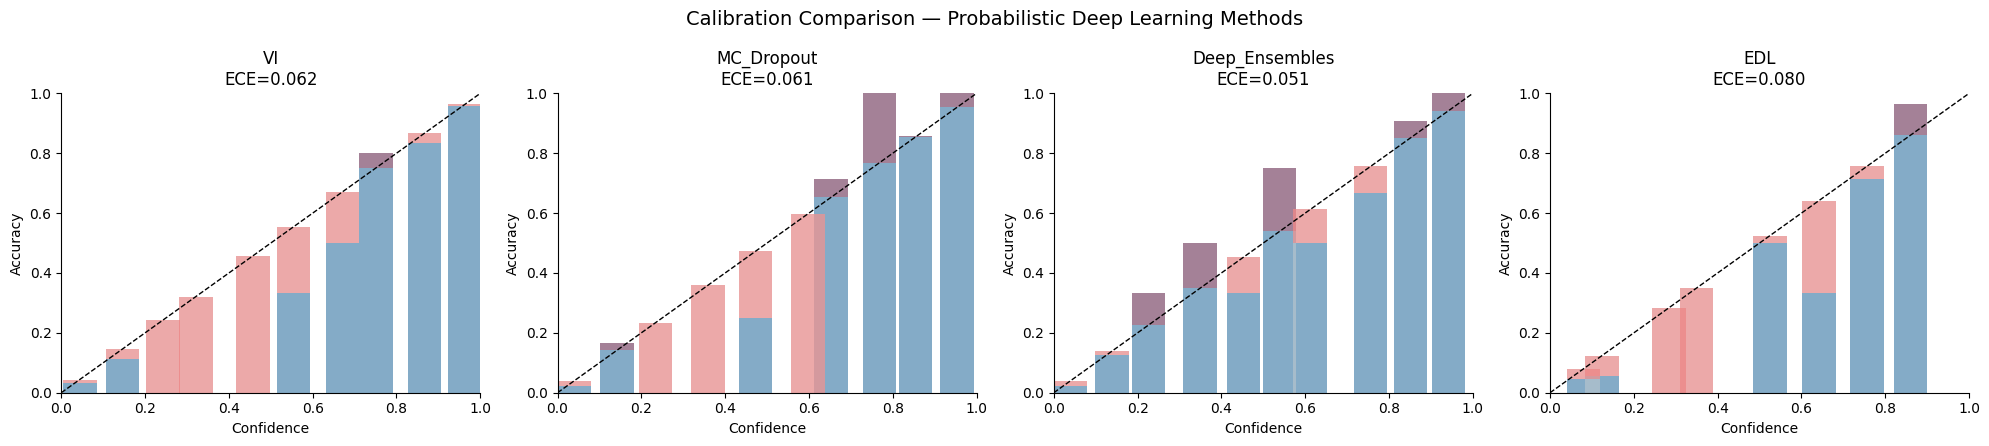

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load results

RESULTS_DIR = "/content"

methods_cfg = {
    "VI": (f"{RESULTS_DIR}/results_vi.csv", "#7F77DD"),
    "MC_Dropout": (f"{RESULTS_DIR}/results_md.csv", "#1D9E75"),
    "Deep_Ensembles": (f"{RESULTS_DIR}/results_de.csv", "#E8A838"),
    "EDL": (f"{RESULTS_DIR}/results_edl.csv", "#D85A30"),
}

dfs = {}

for method, (path, _) in methods_cfg.items():

    if not Path(path).exists():
        raise FileNotFoundError(
            f"Missing results file for {method}: {path}"
        )

    df = pd.read_csv(path)

    required_cols = ["true_label", "mean_pred"]

    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(
            f"{method} is missing required columns: {missing}"
        )

    dfs[method] = df

# Compute calibration metrics

def compute_calibration_metrics(probs, labels, n_bins=10):

    probs = np.asarray(probs)
    labels = np.asarray(labels)

    bin_edges = np.linspace(0, 1, n_bins + 1)

    bin_conf = []
    bin_acc = []
    bin_count = []

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (probs >= bin_edges[i]) &
                (probs <= bin_edges[i + 1])
            )
        else:
            mask = (
                (probs >= bin_edges[i]) &
                (probs < bin_edges[i + 1])
            )

        if mask.sum() == 0:
            continue

        bin_conf.append(probs[mask].mean())
        bin_acc.append(labels[mask].mean())
        bin_count.append(mask.sum())

    bin_conf = np.array(bin_conf)
    bin_acc = np.array(bin_acc)
    bin_count = np.array(bin_count)

    gaps = np.abs(bin_conf - bin_acc)

    ece = np.sum(bin_count * gaps) / np.sum(bin_count)
    mce = np.max(gaps)
    ace = np.mean(gaps)
    brier = np.mean((probs - labels) ** 2)

    return {
        "ECE": ece,
        "MCE": mce,
        "ACE": ace,
        "Brier": brier,
        "bin_means": bin_conf,
        "bin_accs": bin_acc,
    }

# Compute metrics

metrics = {}

for method, df in dfs.items():

    metrics[method] = compute_calibration_metrics(
        probs=df["mean_pred"].values,
        labels=df["true_label"].values,
        n_bins=10,
    )

# Print calibration summary

print("\nCalibration Summary")
print("=" * 80)
print(f"{'Method':18s} | {'ECE':>8} | {'MCE':>8} | {'ACE':>8} | {'Brier':>8}")
print("-" * 80)

order = ["VI", "MC_Dropout", "Deep_Ensembles", "EDL"]

for method in order:

    m = metrics[method]

    print(
        f"{method:18s} | "
        f"{m['ECE']:8.4f} | "
        f"{m['MCE']:8.4f} | "
        f"{m['ACE']:8.4f} | "
        f"{m['Brier']:8.4f}"
    )

# Plot reliability diagrams

def plot_reliability(ax, metric_dict, title):

    conf = metric_dict["bin_means"]
    acc = metric_dict["bin_accs"]

    ax.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=1,
    )

    ax.bar(
        conf,
        acc,
        width=0.08,
        color="#1f77b4",
        alpha=0.9,
    )

    ax.bar(
        conf,
        conf,
        width=0.08,
        color="lightgray",
        alpha=0.5,
    )

    for x, a, c in zip(conf, acc, conf):

        ax.bar(
            x,
            abs(a - c),
            bottom=min(a, c),
            width=0.08,
            color="lightcoral",
            alpha=0.6,
        )

    ax.set_title(
        f"{title}\nECE={metric_dict['ECE']:.3f}"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Generate final figure

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 4.5)
)

fig.suptitle(
    "Calibration Comparison — Probabilistic Deep Learning Methods",
    fontsize=14
)

for ax, method in zip(axes, order):

    plot_reliability(
        ax,
        metrics[method],
        method,
    )

plt.tight_layout()
plt.show()

---

## 🌡️ Part 5 — Temperature Scaling

### 5.1 The idea

Temperature scaling is the simplest and most widely used post-hoc calibration method. It requires no retraining and introduces a single scalar parameter $T > 0$.

Instead of applying softmax directly to the logits $z$, we divide them by $T$ first:

$$\hat{p}_k = \frac{\exp(z_k / T)}{\sum_j \exp(z_j / T)}$$

- **$T > 1$:** logits are shrunk → softmax output is softer → reduces overconfidence
- **$T < 1$:** logits are amplified → softmax output is sharper → reduces underconfidence
- **$T = 1$:** no change

**Crucial property:** temperature scaling does not change the **argmax** of the softmax output. Accuracy is exactly preserved — only the probability values change.

### 5.2 Finding the optimal T

T is found by minimizing the **negative log-likelihood (NLL)** on a held-out validation or calibration set:

$$T^* = \arg\min_T \; \text{NLL}(T) = -\frac{1}{n}\sum_{i=1}^{n} \log \hat{p}_{y_i}(x_i; T)$$

**Limitation of temperature scaling:** it applies the **same correction everywhere**. If a model is overconfident at high confidence but underconfident at low confidence, a single $T$ cannot fix both simultaneously. More flexible post-hoc methods (Platt Scaling, Isotonic Regression) address this at the cost of added complexity.

📌 **Note**

In the following code, the temperature values (T) are estimated directly on the test set and then applied back to the same data. This is not strictly correct from an evaluation perspective, since it introduces data leakage and can lead to overly optimistic calibration results.

We do this here only because the test predictions were not separately stored with a dedicated calibration (validation) split, and this is an educational implementation aimed at demonstrating the effect of temperature scaling in a clear and practical way.

In real-world applications, T must always be learned on a separate held-out calibration set and then applied unchanged to the test set. This ensures that calibration performance (e.g., ECE, MCE, ACE, Brier score) is evaluated fairly and reflects true generalization to unseen data.



Temperature Scaling Results
Method             |      T | ECE before |  ECE after
--------------------------------------------------------------------------------
VI                 |   0.73 |     0.0618 |     0.0574
MC_Dropout         |   0.96 |     0.0608 |     0.0461
Deep_Ensembles     |   0.62 |     0.0514 |     0.0374
EDL                |   0.62 |     0.0802 |     0.0445


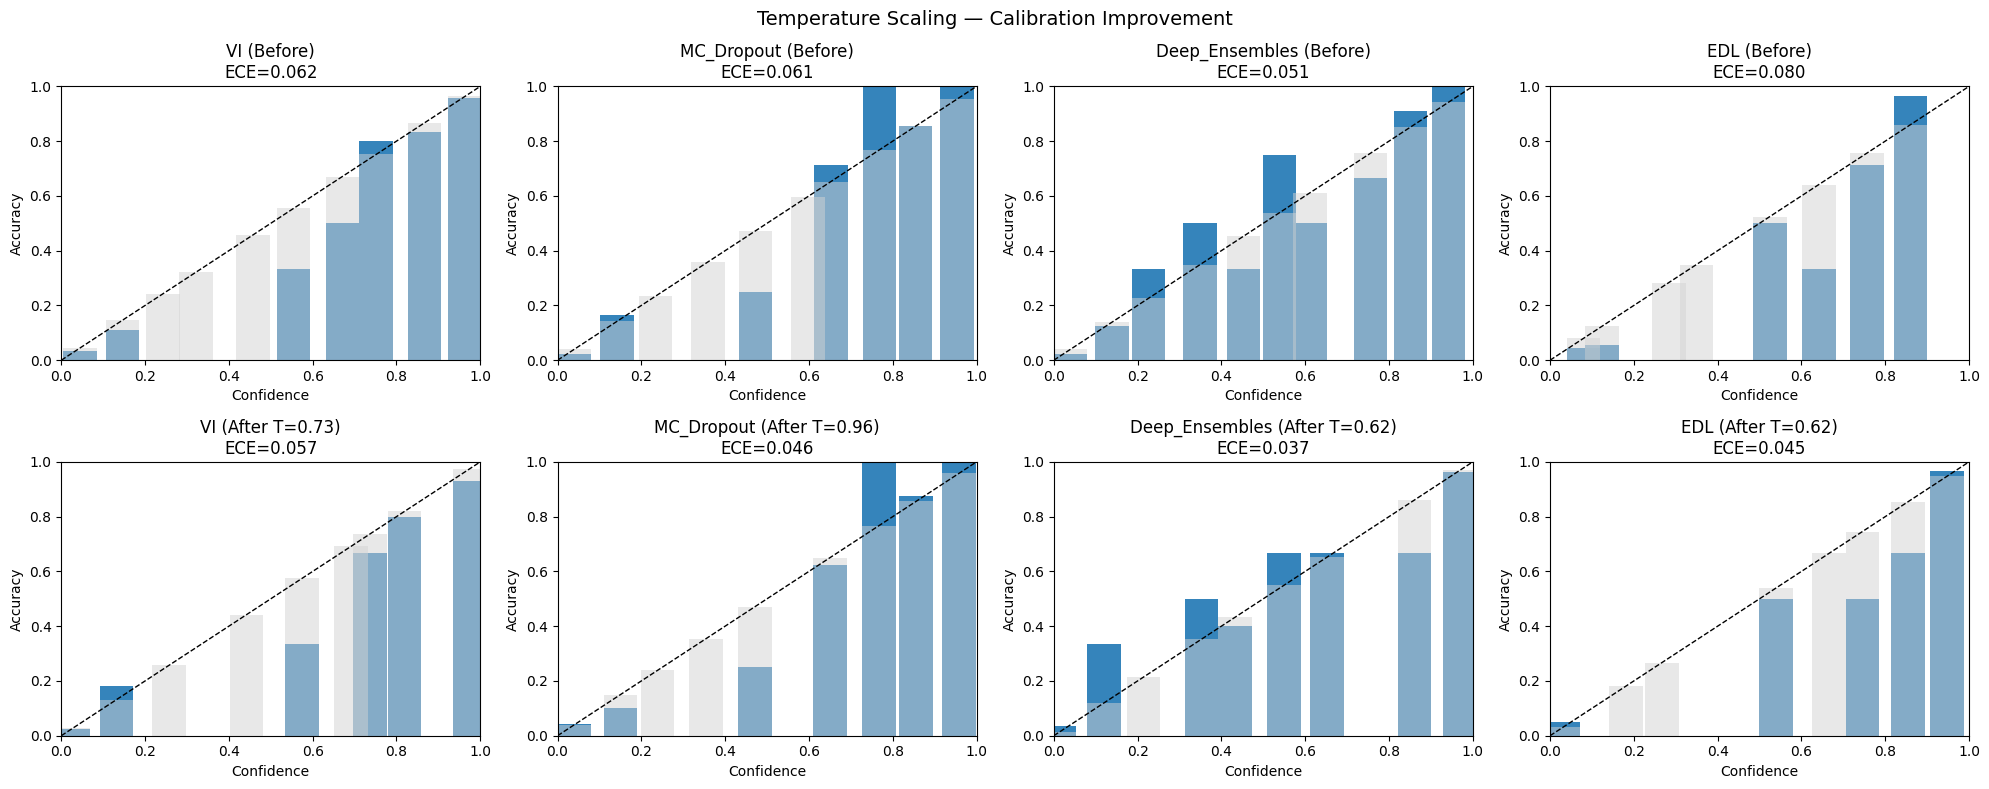

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Temperature scaling

def temperature_scale(probs, T):

    probs = np.clip(probs, 1e-6, 1 - 1e-6)

    logits = np.log(probs / (1 - probs))
    scaled_logits = logits / T

    return 1 / (1 + np.exp(-scaled_logits))

# Compute calibration metrics

def compute_calibration_metrics(probs, labels, n_bins=10):

    probs = np.asarray(probs)
    labels = np.asarray(labels)

    bin_edges = np.linspace(0, 1, n_bins + 1)

    bin_conf = []
    bin_acc = []
    bin_count = []

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (probs >= bin_edges[i]) &
                (probs <= bin_edges[i + 1])
            )
        else:
            mask = (
                (probs >= bin_edges[i]) &
                (probs < bin_edges[i + 1])
            )

        if mask.sum() == 0:
            continue

        bin_conf.append(probs[mask].mean())
        bin_acc.append(labels[mask].mean())
        bin_count.append(mask.sum())

    bin_conf = np.array(bin_conf)
    bin_acc = np.array(bin_acc)
    bin_count = np.array(bin_count)

    gaps = np.abs(bin_conf - bin_acc)

    ece = np.sum(bin_count * gaps) / np.sum(bin_count)

    return {
        "ECE": ece,
        "bin_means": bin_conf,
        "bin_accs": bin_acc,
    }

# Find optimal temperature

def find_best_temperature(probs, labels):

    best_T = 1.0
    best_ece = np.inf

    for T in np.linspace(0.5, 5.0, 40):

        scaled_probs = temperature_scale(probs, T)

        ece = compute_calibration_metrics(
            scaled_probs,
            labels
        )["ECE"]

        if ece < best_ece:
            best_ece = ece
            best_T = T

    return best_T

# Reliability diagram

def plot_reliability(ax, metrics, title):

    conf = metrics["bin_means"]
    acc = metrics["bin_accs"]

    ax.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=1,
    )

    ax.bar(
        conf,
        acc,
        width=0.08,
        color="#1f77b4",
        alpha=0.9,
    )

    ax.bar(
        conf,
        conf,
        width=0.08,
        color="lightgray",
        alpha=0.5,
    )

    ax.set_title(
        f"{title}\nECE={metrics['ECE']:.3f}"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Apply temperature scaling

order = ["VI", "MC_Dropout", "Deep_Ensembles", "EDL"]

results_before = {}
results_after = {}
temperatures = {}

for method in order:

    df = dfs[method]

    probs = df["mean_pred"].values
    labels = df["true_label"].values

    results_before[method] = compute_calibration_metrics(
        probs,
        labels,
    )

    T = find_best_temperature(
        probs,
        labels,
    )

    temperatures[method] = T

    scaled_probs = temperature_scale(
        probs,
        T,
    )

    results_after[method] = compute_calibration_metrics(
        scaled_probs,
        labels,
    )

# Print summary table

print("\nTemperature Scaling Results")
print("=" * 80)
print(f"{'Method':18s} | {'T':>6} | {'ECE before':>10} | {'ECE after':>10}")
print("-" * 80)

for method in order:

    print(
        f"{method:18s} | "
        f"{temperatures[method]:6.2f} | "
        f"{results_before[method]['ECE']:10.4f} | "
        f"{results_after[method]['ECE']:10.4f}"
    )

# Generate figure

fig, axes = plt.subplots(
    2,
    4,
    figsize=(20, 8),
)

fig.suptitle(
    "Temperature Scaling — Calibration Improvement",
    fontsize=14,
)

for col, method in enumerate(order):

    plot_reliability(
        axes[0, col],
        results_before[method],
        f"{method} (Before)",
    )

    plot_reliability(
        axes[1, col],
        results_after[method],
        f"{method} (After T={temperatures[method]:.2f})",
    )

plt.tight_layout()
plt.show()

---

## 🗂️ Part 6 — Other calibration methods (conceptual)

Temperature scaling is the go-to first fix for overconfidence, but it has one structural limitation: a single scalar $T$ applies the same correction everywhere. If a model is overconfident at high confidence but reasonably calibrated at low confidence, temperature scaling will either overcorrect one region or undercorrect the other.

Two more flexible alternatives exist:

---

### Platt Scaling

Instead of a single temperature scalar, Platt Scaling fits a **sigmoid function** to the logits:

$$\hat{p} = \sigma(a \cdot z + b) = \frac{1}{1 + \exp(-(az + b))}$$

where $a$ and $b$ are learned from the calibration set. This is equivalent to fitting a logistic regression on the raw logits — two parameters instead of one. Platt Scaling can correct both the sharpness ($a$) and the offset ($b$) of the confidence distribution independently. It is particularly useful when the model is systematically biased toward one class.

**Limitation:** still a monotonic transformation — it cannot handle non-monotonic miscalibration (where the model is overconfident in one confidence range and underconfident in another).

---

### Isotonic Regression

Isotonic regression fits a **piecewise constant monotone function** from predicted confidence to true accuracy. It is the most flexible of the three methods — it can correct any shape of miscalibration, as long as the true accuracy is monotonically related to predicted confidence.

**Limitation:** it requires more calibration data than Platt Scaling or temperature scaling to fit reliably. With small calibration sets, isotonic regression can overfit — producing a well-calibrated-looking training curve but poor generalization to new data. In medical imaging settings with limited labelled data, temperature scaling is often preferred precisely because its single parameter is less prone to overfitting.

---

> **💡 Practical rule of thumb**  
> Start with temperature scaling. If the reliability diagram shows a complex non-monotonic pattern (overconfident in some regions, underconfident in others), consider Platt Scaling. Use isotonic regression only when you have a large, representative calibration set and have verified that it generalises to your test distribution.

---

## 🚫 Note: Why Conformal Prediction is excluded

This notebook excludes Conformal Prediction from calibration analysis because it does not produce probabilities. Instead of probabilistic outputs used in reliability diagrams, ECE, or Brier score, it produces prediction sets with coverage guarantees. Calibration metrics are therefore not applicable. Conformal Prediction is evaluated separately using coverage and efficiency metrics, since its goal is guaranteed set validity rather than probability calibration.

---

## 📚 Part 7 — Recommended reading

These are the most cited and most useful calibration references to know. The first few establish the modern calibration problem in deep learning, and the later ones show how calibration is measured, improved, and stress-tested in practice. 🗺️

**[On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599)**  
*Guo, Pleiss, Sun & Weinberger, 2017 — ICML*  
The modern calibration paper that made temperature scaling standard. It is the best starting point for understanding why deep networks are often overconfident and how calibration is usually measured.

**[Measuring Calibration in Deep Learning](https://arxiv.org/abs/1905.11001)**  
*Kull, Silva Filho & Flach, 2019*  
A widely cited paper that sharpens the definition of calibration, discusses practical estimation issues, and explains why common metrics like ECE can be deceptive if used carelessly.

**[Beyond Temperature Scaling: Obtaining Well-Calibrated Multiclass Probabilities with Dirichlet Calibration](https://arxiv.org/abs/1910.12656)**  
*Kull, Filho & Flach, 2019 — NeurIPS*  
A key extension of temperature scaling that calibrates class probabilities more flexibly. Very useful when a single scalar temperature is not enough.

**[Calibrating Neural Networks using Focal Loss](https://arxiv.org/abs/2002.08591)**  
*Mukhoti et al., 2020*  
A practical paper showing how loss design affects calibration. Important because it connects the training objective to the confidence behavior you see later.

**[Calibration of Neural Networks for Medical Imaging](https://arxiv.org/abs/2001.09801)**  
*Minderer et al., 2021*  
A useful medical-imaging-focused calibration reference. It connects the general calibration literature to the practical question of trustworthy clinical deployment.

---

## ✅ Session summary

| Concept | Key takeaway |
|---|---|
| 🎯 **Calibration** | Predicted confidence should match observed correctness frequency. A model that says 80% should be right about 80% of the time. |
| ⚖️ **Calibration vs accuracy** | Accuracy asks whether predictions are correct overall; calibration asks whether confidence is trustworthy. A model can be accurate and still badly calibrated. |
| 🚨 **Overconfidence** | The most dangerous failure mode in clinical AI. The model sounds certain even when it is wrong. |
| 📊 **ECE and reliability diagrams** | Standard tools for measuring and visualizing calibration quality. |
| 📈 **Brier score** | A proper scoring rule that measures probabilistic accuracy and calibration together. |
| 🌡️ **Temperature scaling** | The simplest and most common post-hoc calibration fix. It rescales logits with a single scalar temperature. |
| 🔧 **Platt and isotonic calibration** | More flexible calibration methods that can correct miscalibration beyond a single temperature. |
| 🏥 **Clinical value** | A calibrated model is more trustworthy for triage, escalation, and decision support. |


> **➡️ Next: Session 17: Risk–Coverage Analysis**  
> Session 17 shifts the focus from calibrated probabilities to selective prediction: when the model should abstain, defer, or route a case to a human instead of forcing an answer. That is where uncertainty becomes an operational safety tool, not just a numerical score